<h1 style="text-align:center; color:#2c7be5;">Проект: Дашборд конверсий</h1>

<h2 style="color:#343a40; font-style:italic;">ШАГ 1. Подготовка к работе с данными</h2>

<p style="color:#6c757d;">На данном этапе подключаются необходимые библиотеки для работы с данными, получения информации из API и построения визуализаций.</p>

In [65]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pathlib import Path

<h2 style="color:#343a40; font-style:italic;">ШАГ 2. Запросы к API</h2>

<p style="color:#6c757d;">Загрузка переменных окружения и получение параметров для работы с API: адрес сервиса и временной диапазон данных.</p>

In [66]:
load_dotenv()

API_URL = os.getenv('API_URL')
DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')

<p style="color:#6c757d;">Получение данных из API по визитам и регистрациям за заданный период с последующим преобразованием в датафреймы для дальнейшего анализа.</p>

In [67]:
visits = pd.DataFrame(
    requests.get(
        f'{API_URL}/visits',
        params={'begin': DATE_BEGIN, 'end': DATE_END}
    ).json()
)

registrations = pd.DataFrame(
    requests.get(
        f'{API_URL}/registrations',
        params={'begin': DATE_BEGIN, 'end': DATE_END}
    ).json()
)

<p style="color:#6c757d;">Переименование столбцов для приведения данных к единому формату и удобства дальнейшей обработки.</p>

In [68]:
visits = visits.rename(columns={'visit_id': 'uuid', 'datetime': 'date'})
registrations = registrations.rename(columns={'datetime': 'date'})

<p style="color:#6c757d;">Загрузка данных по рекламным кампаниям из локального CSV-файла.</p>

In [69]:
ads = pd.read_csv('./ads.csv')

<p style="color:#6c757d;">Просмотр первых строк датасета визитов для проверки структуры и корректности загрузки данных.</p>

In [70]:
visits.head()

,uuid,platform,user_agent,date
0,ea3c939a-8d67-4616-ba89-7a41caffef66,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-04-05T20:45:29
1,dacf4025-7670-4566-89a0-1b4b9e5cdf3a,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:15....,2023-04-08T23:55:33
2,dacf4025-7670-4566-89a0-1b4b9e5cdf3a,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:15....,2023-04-07T22:29:21
3,ea6871b4-da5c-42c9-9783-e16db10f8a2c,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2023-04-08T13:57:22
4,ea6871b4-da5c-42c9-9783-e16db10f8a2c,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,2023-04-06T12:02:52


<p style="color:#6c757d;">Просмотр первых строк датасета регистраций для проверки структуры и корректности загрузки данных.</p>

In [71]:
registrations.head()

,date,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google


<p style="color:#6c757d;">Просмотр первых строк датасета по рекламой компании для проверки структуры и корректности загрузки данных.</p>

In [72]:
ads.head()

,date,utm_source,utm_medium,utm_campaign,cost
0,2023-03-01T10:54:41,google,cpc,advanced_algorithms_series,212
1,2023-03-02T10:32:35,google,cpc,advanced_algorithms_series,252
2,2023-03-03T19:21:40,google,cpc,advanced_algorithms_series,202
3,2023-03-04T17:52:04,google,cpc,advanced_algorithms_series,223
4,2023-03-05T05:35:13,google,cpc,advanced_algorithms_series,265


<h2 style="color:#343a40; font-style:italic;">ШАГ 3. Расчет метрик</h2>

<p style="color:#6c757d;">Исключение бот-трафика из данных о визитах для корректного расчета пользовательских метрик.</p>

In [73]:
visits = visits[~visits['user_agent'].str.contains('bot', case=False, na=False)].copy()

<p style="color:#6c757d;">Преобразование полей даты к удобному формату и выделение календарной даты для последующей агрегации.</p>

In [74]:
visits = visits[~visits['user_agent'].str.contains('bot', case=False, na=False)].copy()

visits['date'] = pd.to_datetime(visits['date'])
registrations['date'] = pd.to_datetime(registrations['date'])

visits = visits.sort_values(['uuid', 'date']).drop_duplicates(subset='uuid', keep='last')

visits['date_group'] = visits['date'].dt.normalize()
registrations['date_group'] = registrations['date'].dt.normalize()

<p style="color:#6c757d;">Агрегация данных по датам и платформам для расчета количества визитов и регистраций.</p>

In [75]:
visits_grouped = (
    visits
    .groupby(['date_group', 'platform'])
    .size()
    .reset_index(name='visits')
)

registrations_grouped = (
    registrations
    .groupby(['date_group', 'platform'])
    .size()
    .reset_index(name='registrations')
)

<p style="color:#6c757d;">Объединение агрегированных данных по визитам и регистрациям с заполнением пропусков нулевыми значениями.</p>

In [76]:
df = pd.merge(
    visits_grouped,
    registrations_grouped,
    on=['date_group', 'platform'],
    how='outer'
)

df['visits'] = df['visits'].fillna(0).astype(int)
df['registrations'] = df['registrations'].fillna(0).astype(int)

<p style="color:#6c757d;">Расчет конверсии по платформам и сортировка итогового датафрейма для дальнейшего сохранения и визуализации.</p>

In [77]:
df['conversion'] = 0.0
mask = df['visits'] > 0
df.loc[mask, 'conversion'] = (df.loc[mask, 'registrations'] / df.loc[mask, 'visits']) * 100

df = df.sort_values(['date_group', 'platform'])

<p style="color:#6c757d;">Просмотр первых строк итогового датафрейма с рассчитанными метриками для проверки корректности объединения данных и расчета конверсии.</p>

In [81]:
df.head()

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355


<p style="color:#6c757d;">Подготовка итогового датафрейма и сохранение результатов в формате JSON для последующего использования и проверки.</p>

In [83]:
conversion_to_save = df.copy()
conversion_to_save = conversion_to_save.sort_values('date_group')
conversion_to_save.to_json('./conversion.json', date_format='epoch')

/var/folders/m9/30jkzgfd1lb4x6dpxbj86td80000gn/T/ipykernel_31742/800859477.py:3: Pandas4Warning: 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  conversion_to_save.to_json('./conversion.json', date_format='epoch')


<h2 style="color:#343a40; font-style:italic;">ШАГ 4. Добавление данных по рекламной кампании</h2>

<p style="color:#6c757d;">Исключение бот-трафика из данных о визитах для корректного расчета пользовательских метрик.</p>

In [84]:
visits = visits[~visits['user_agent'].str.contains('bot', case=False, na=False)].copy()

In [85]:
ads['date'] = pd.to_datetime(ads['date'])
ads['date_group'] = ads['date'].dt.normalize()

<p style="color:#6c757d;">Агрегация данных по визитам и регистрациям для расчета общего количества посещений и регистраций за каждый день.</p>

In [86]:
visits_grouped = (
    visits
    .groupby('date_group')
    .size()
    .reset_index(name='visits')
)

registrations_grouped = (
    registrations
    .groupby('date_group')
    .size()
    .reset_index(name='registrations')
)

<p style="color:#6c757d;">Объединение дневных данных по визитам и регистрациям с заполнением пропусков нулевыми значениями.</p>

In [87]:
base_df = pd.merge(
    visits_grouped,
    registrations_grouped,
    on='date_group',
    how='outer'
)

base_df['visits'] = base_df['visits'].fillna(0).astype(int)
base_df['registrations'] = base_df['registrations'].fillna(0).astype(int)

<p style="color:#6c757d;">Агрегация данных по рекламным кампаниям для расчета суммарных затрат по каждой дате и каждой кампании.</p>

In [88]:
ads_grouped = (
    ads
    .groupby(['date_group', 'utm_campaign'], as_index=False)
    .agg({'cost': 'sum'})
)

<p style="color:#6c757d;">Объединение дневных метрик с данными по рекламным кампаниям и заполнение отсутствующих значений для дат без рекламной активности.</p>

In [89]:
result = pd.merge(
    base_df,
    ads_grouped,
    on='date_group',
    how='left'
)

result['cost'] = result['cost'].fillna(0)
result['utm_campaign'] = result['utm_campaign'].fillna('none')

result = result.sort_values('date_group').reset_index(drop=True)

<p style="color:#6c757d;">Подготовка итогового датафрейма и сохранение результатов в файл ads.json для последующего использования и проверки.</p>

In [55]:
ads_to_save = result.copy()
ads_to_save['date_group'] = ads_to_save['date_group'].astype(str)
ads_to_save.to_json('./ads.json')

<h2 style="color:#343a40; font-style:italic;">ШАГ 5. Визуализация</h2>

In [56]:
p = Path.cwd()
d = p / 'charts'
d.mkdir(exist_ok=True)

<h2 style="color:#343a40; font-style:italic;">Итоговые визиты</h2>

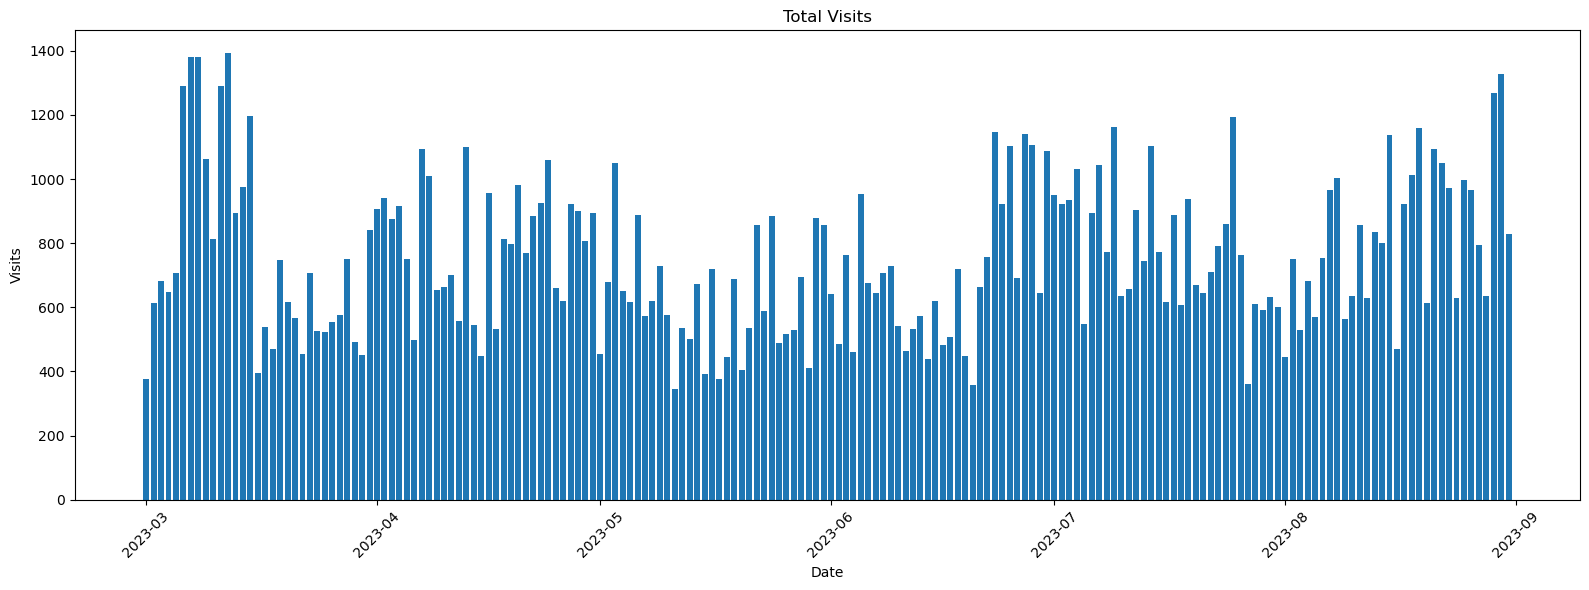

In [57]:
total_visits = df.groupby('date_group', as_index=False)['visits'].sum()

plt.figure(figsize=(16, 6))

plt.bar(total_visits['date_group'], total_visits['visits'])

plt.title('Total Visits')
plt.xlabel('Date')
plt.ylabel('Visits')

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('./charts/total_visits.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Итоговые визиты с разбивкой по платформам</h2>

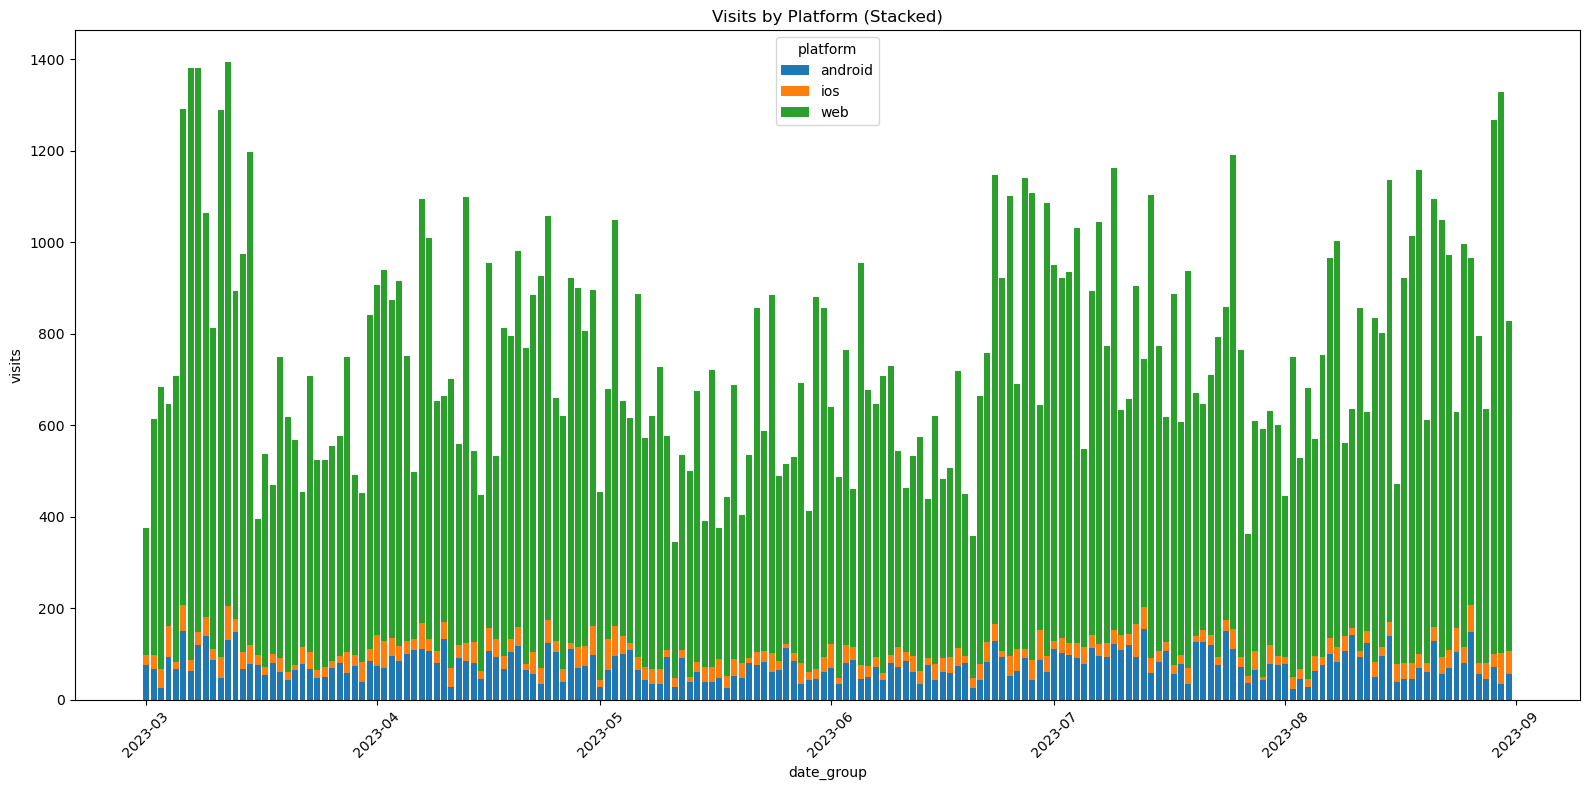

In [58]:
visits_platform = df.pivot_table(
    index='date_group',
    columns='platform',
    values='visits',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(16, 8))

plt.bar(visits_platform.index, visits_platform['android'], label='android')
plt.bar(
    visits_platform.index,
    visits_platform['ios'],
    bottom=visits_platform['android'],
    label='ios'
)
plt.bar(
    visits_platform.index,
    visits_platform['web'],
    bottom=visits_platform['android'] + visits_platform['ios'],
    label='web'
)

plt.title('Visits by Platform (Stacked)')
plt.xlabel('date_group')
plt.ylabel('visits')
plt.xticks(rotation=45)
plt.legend(title='platform')
plt.tight_layout()
plt.savefig('./charts/visits_by_platform.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Итоговые регистрации</h2>

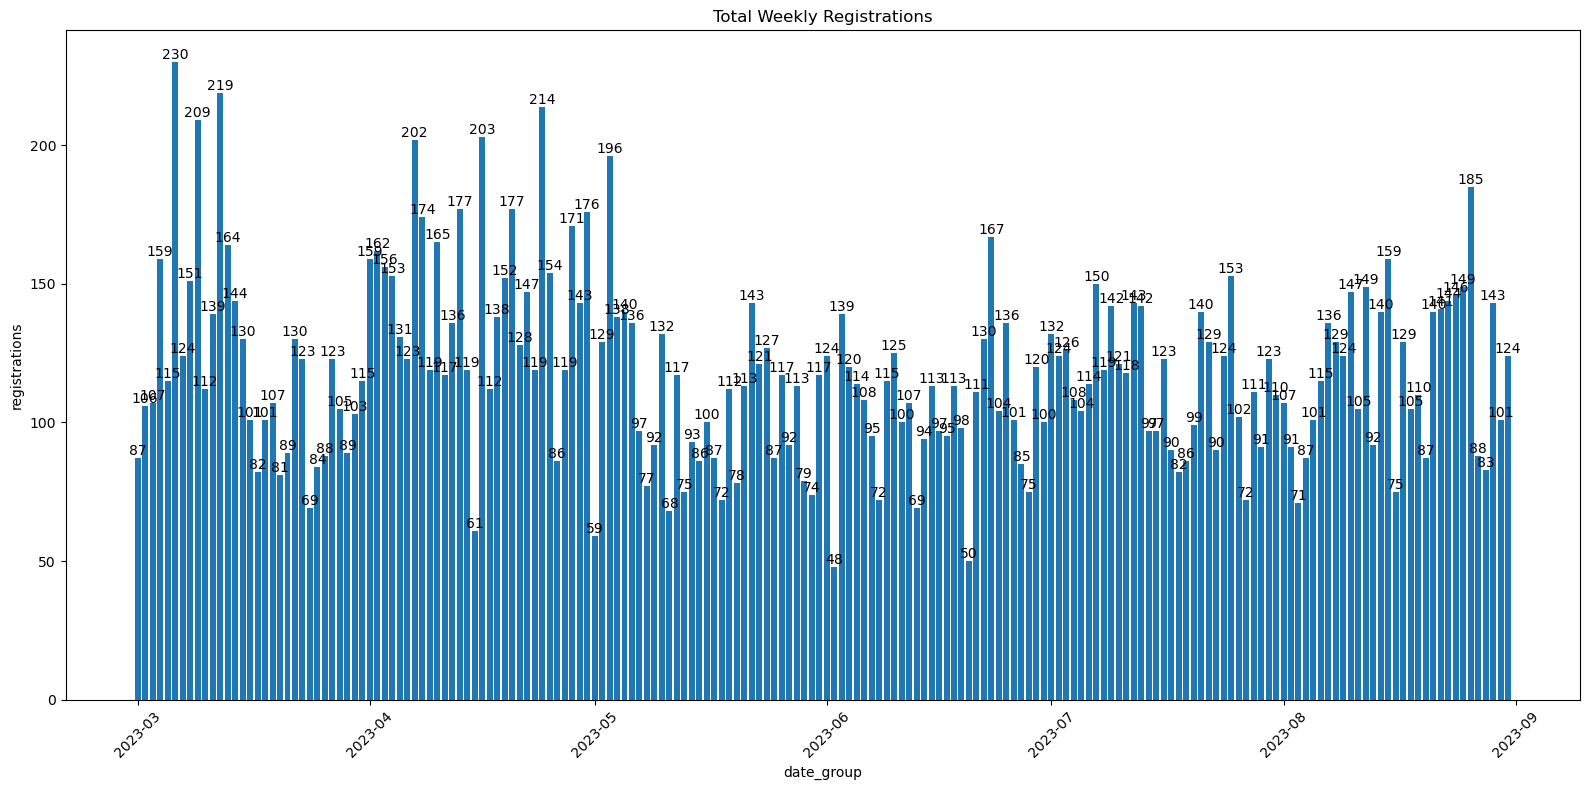

In [59]:
total_registrations = df.groupby('date_group', as_index=False)['registrations'].sum()

plt.figure(figsize=(16, 8))

bars = plt.bar(total_registrations['date_group'], total_registrations['registrations'])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.title('Total Weekly Registrations')
plt.xlabel('date_group')
plt.ylabel('registrations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('./charts/total_registrations.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Итоговые регистрации с разбивкой по платформе</h2>

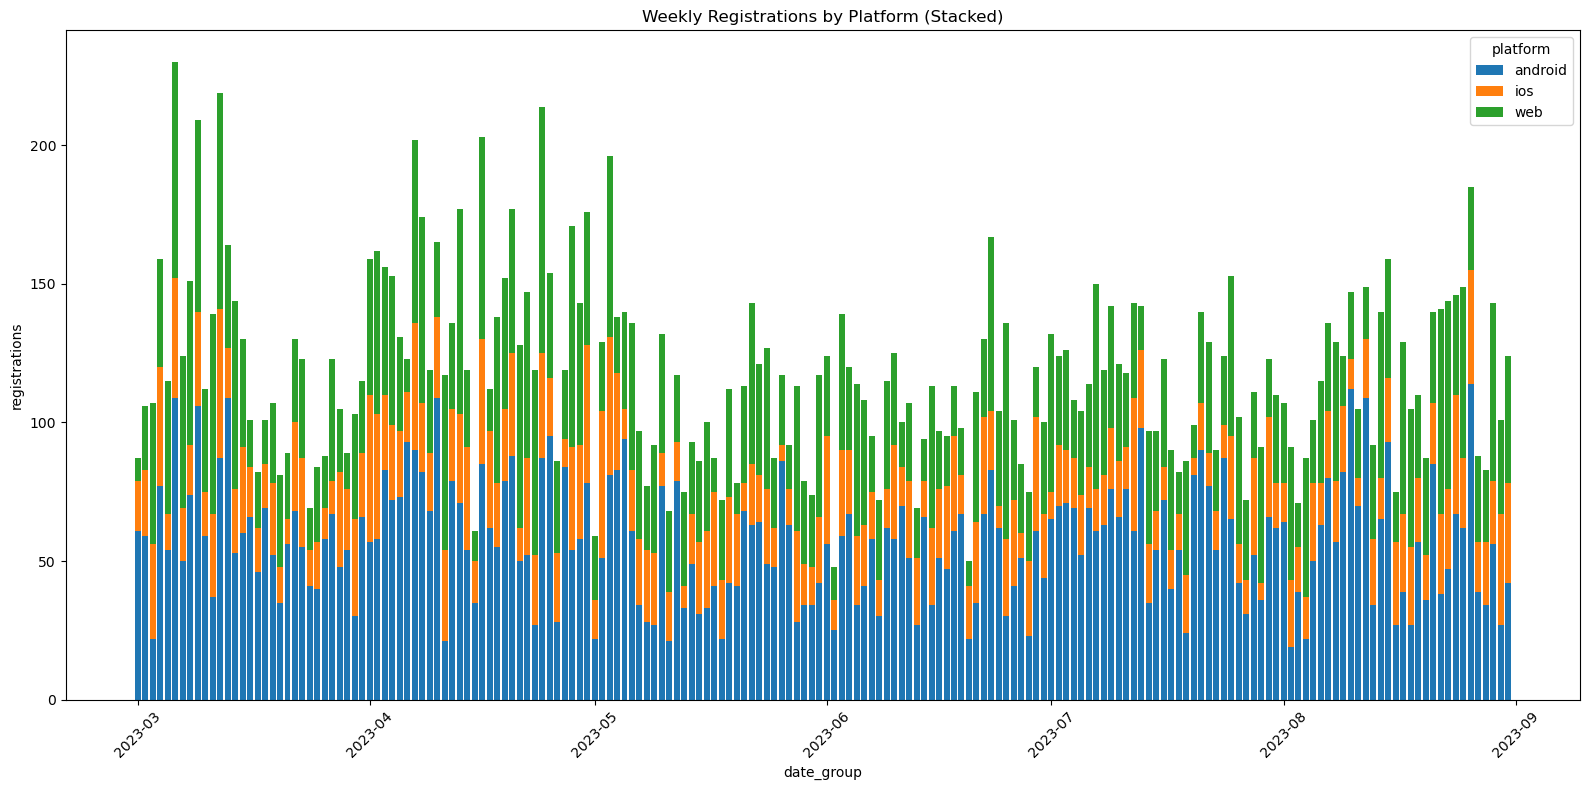

In [60]:
registrations_platform = df.pivot_table(
    index='date_group',
    columns='platform',
    values='registrations',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(16, 8))

plt.bar(registrations_platform.index, registrations_platform['android'], label='android')

plt.bar(
    registrations_platform.index,
    registrations_platform['ios'],
    bottom=registrations_platform['android'],
    label='ios'
)

plt.bar(
    registrations_platform.index,
    registrations_platform['web'],
    bottom=registrations_platform['android'] + registrations_platform['ios'],
    label='web'
)

plt.title('Weekly Registrations by Platform (Stacked)')
plt.xlabel('date_group')
plt.ylabel('registrations')

plt.xticks(rotation=45)
plt.legend(title='platform')

plt.tight_layout()
plt.savefig('./charts/registrations_by_platform.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Итоговые конверсии</h2>

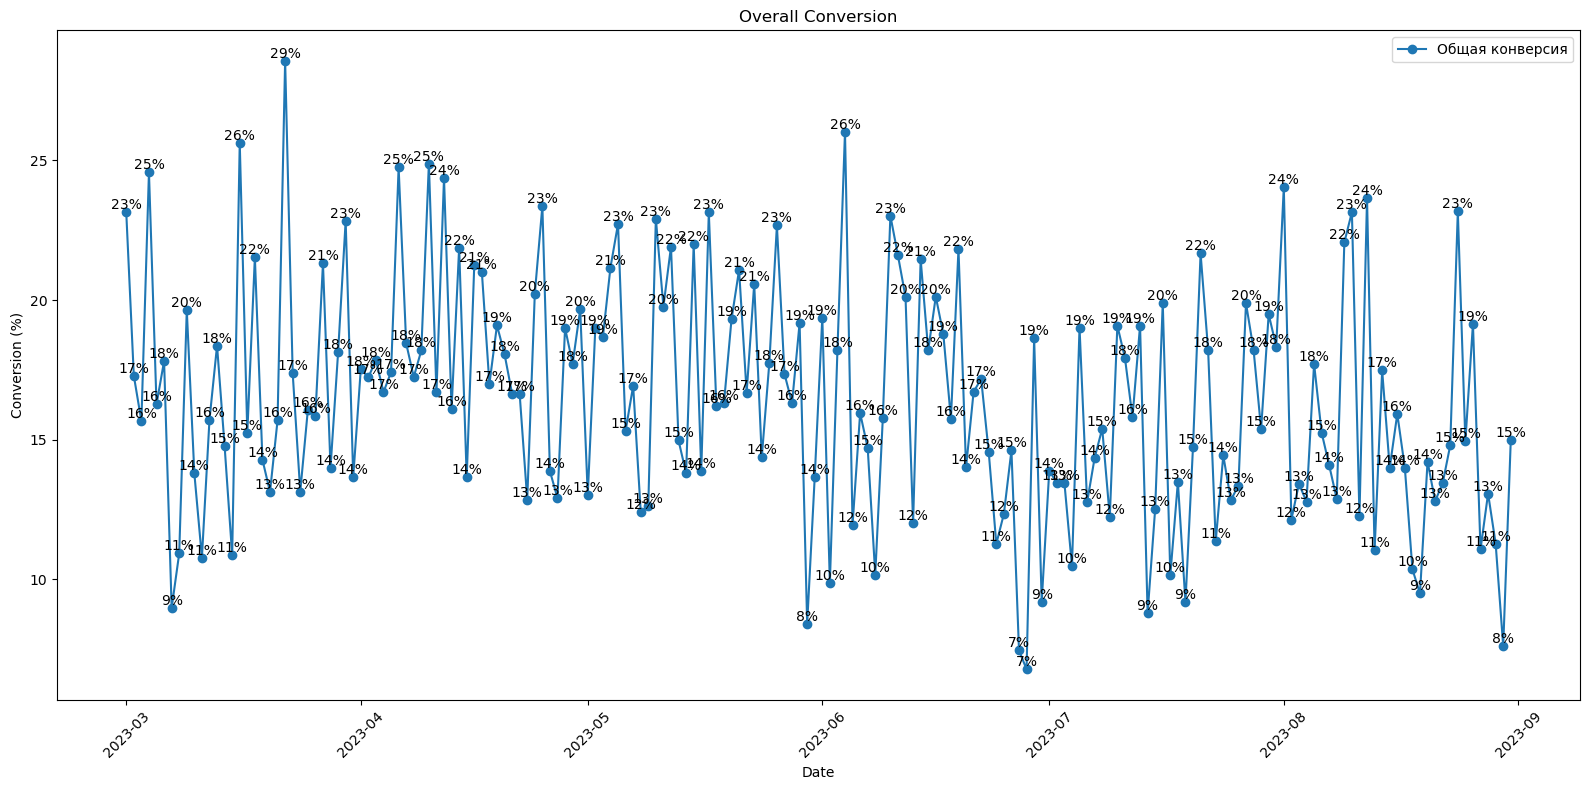

In [61]:
conversion_total = (
    df
    .groupby('date_group', as_index=False)
    .agg({
        'visits': 'sum',
        'registrations': 'sum'
    })
)

conversion_total['conversion'] = (
    conversion_total['registrations'] / conversion_total['visits']
) * 100


plt.figure(figsize=(16, 8))

plt.plot(
    conversion_total['date_group'],
    conversion_total['conversion'],
    marker='o',
    label='Общая конверсия'
)

for x, y in zip(conversion_total['date_group'], conversion_total['conversion']):
    plt.text(x, y, f'{int(round(y))}%', ha='center', va='bottom')

plt.title('Overall Conversion')
plt.xlabel('Date')
plt.ylabel('Conversion (%)')

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.savefig('./charts/overall_conversion.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Конверсия по каждой платформе</h2>

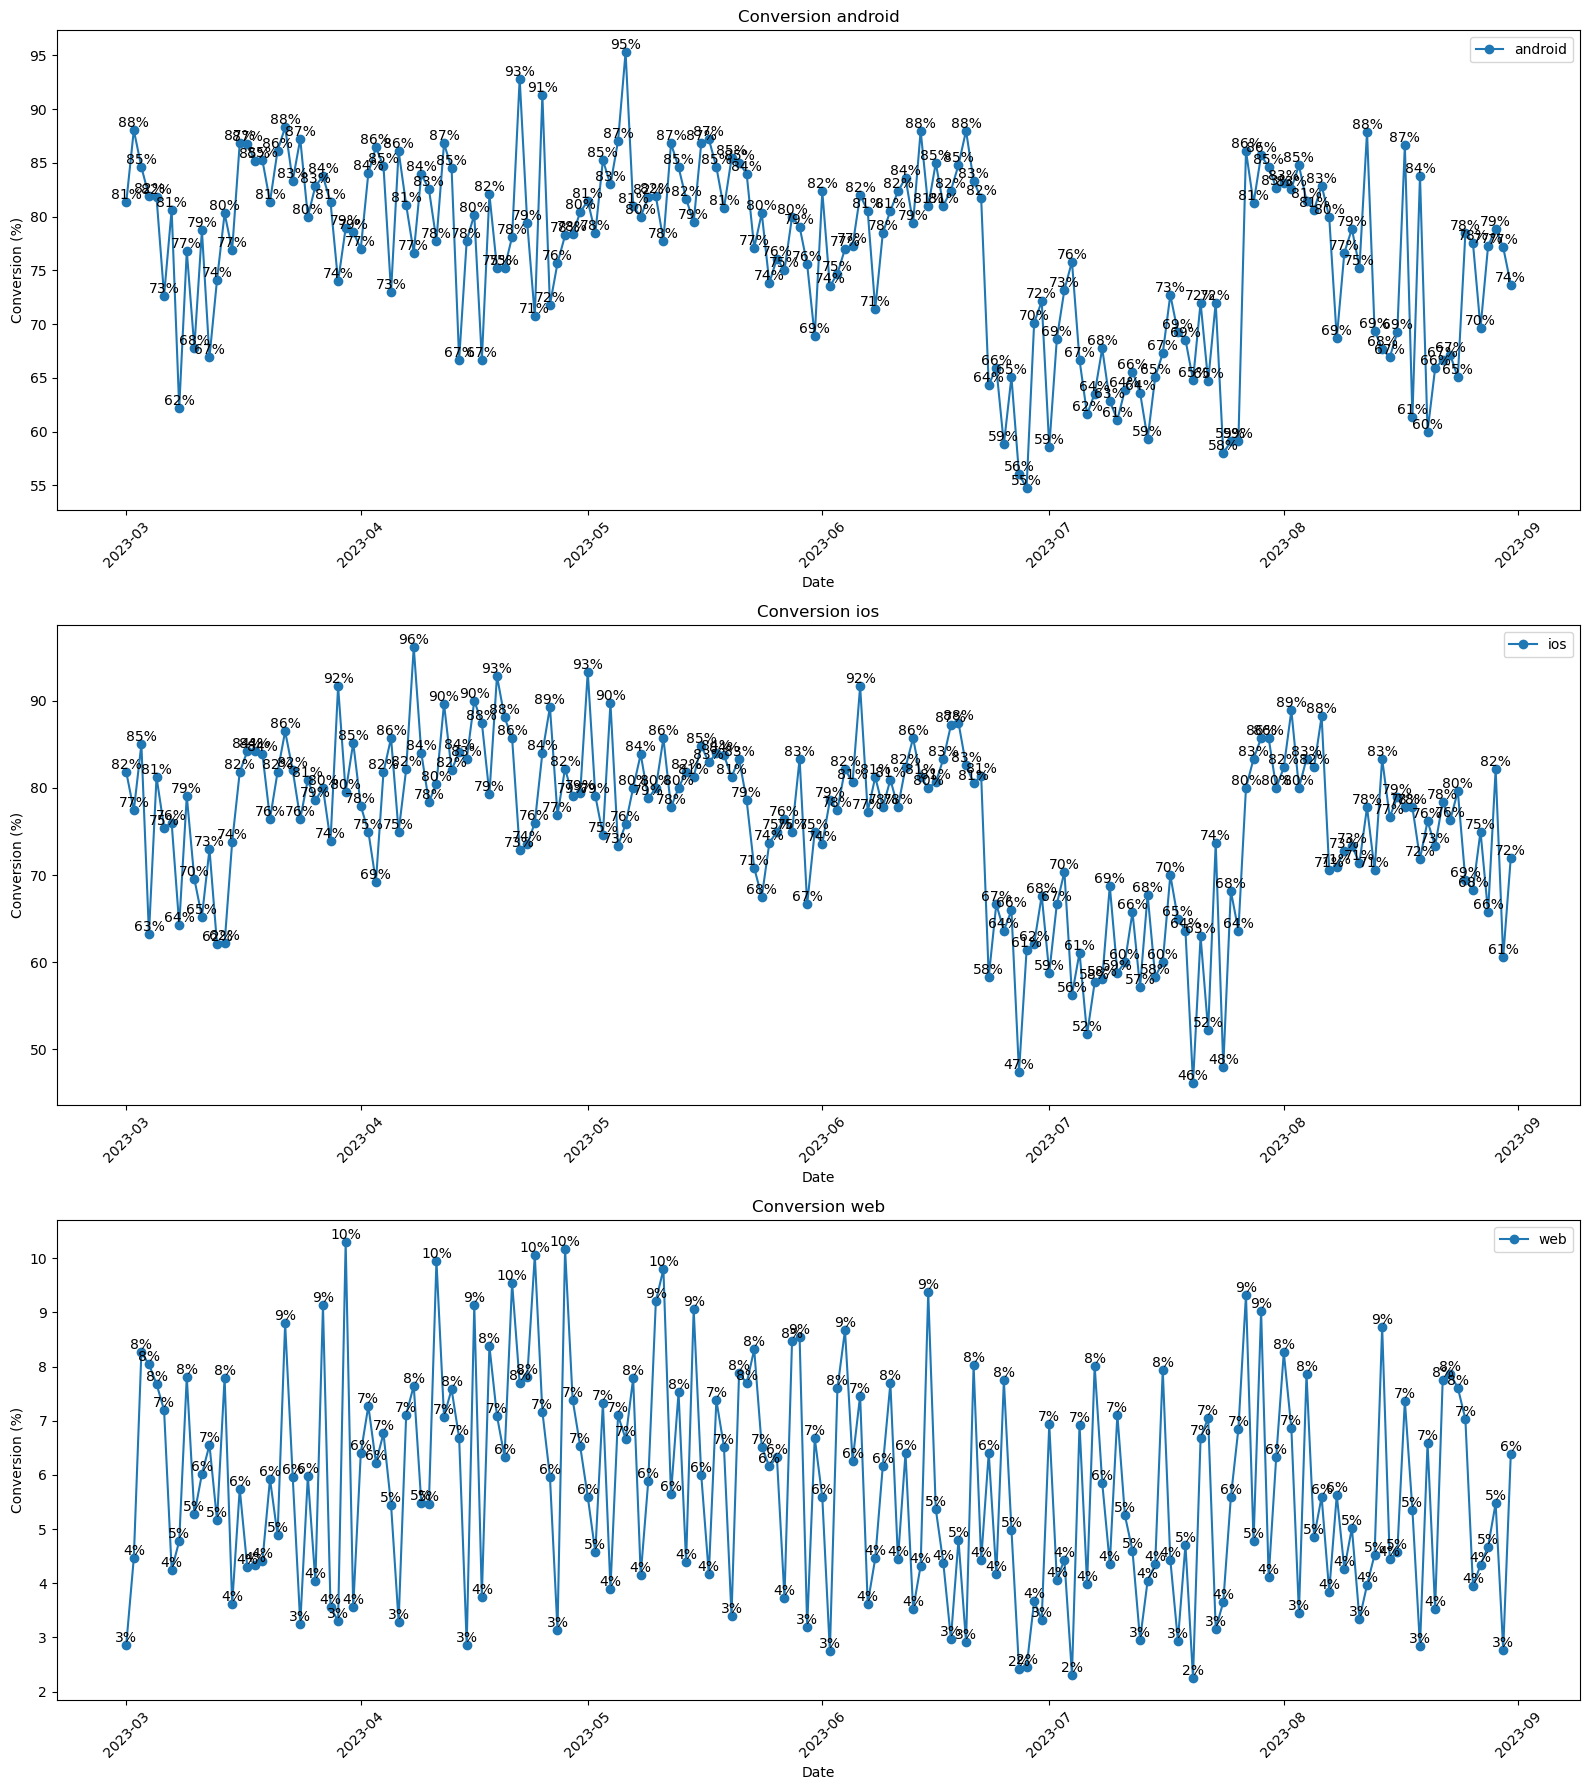

In [62]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

platforms = ['android', 'ios', 'web']


df['date_group'] = pd.to_datetime(df['date_group'])

for i, platform in enumerate(platforms):
    data = df[df['platform'] == platform].sort_values('date_group')

    axes[i].plot(
        data['date_group'],
        data['conversion'],
        marker='o',
        label=platform
    )

  
    for x, y in zip(data['date_group'], data['conversion']):
        axes[i].text(x, y, f'{int(round(y))}%', ha='center', va='bottom')

    axes[i].set_title(f'Conversion {platform}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Conversion (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.tight_layout()
plt.savefig('./charts/conversion_by_platform.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Стоимости реклам</h2>

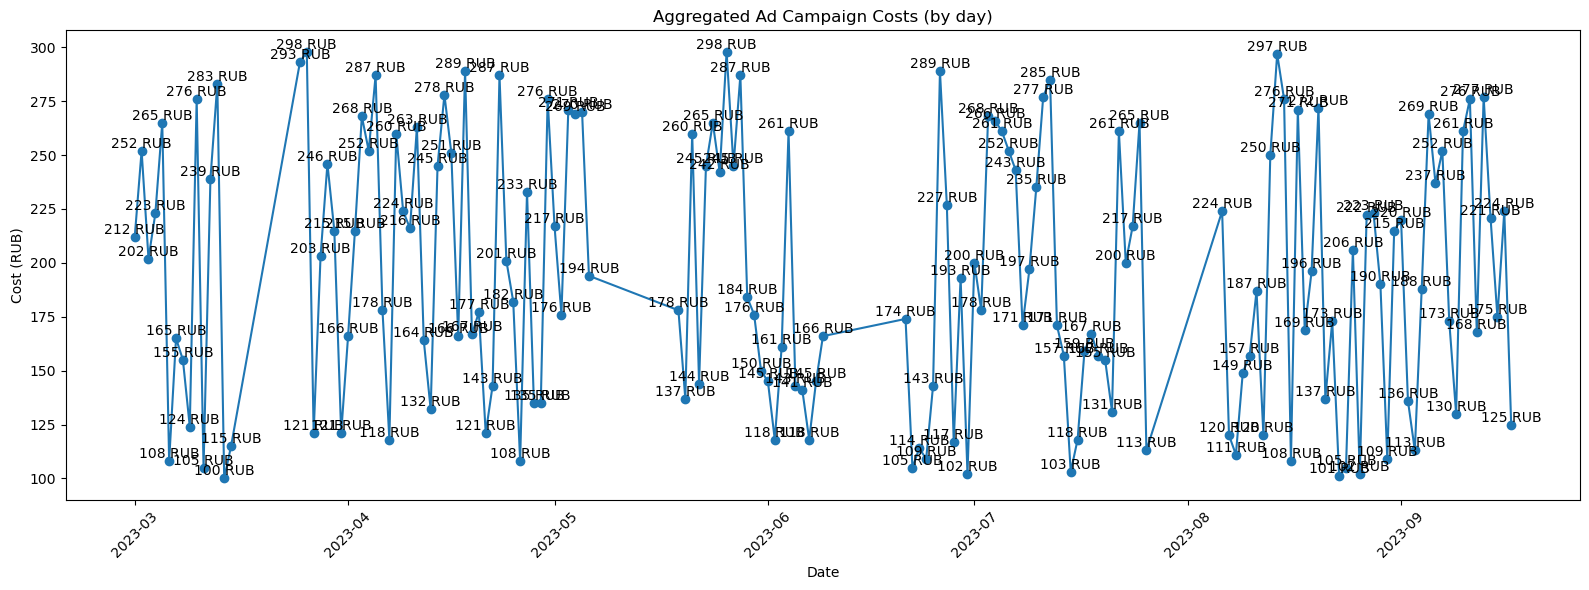

In [63]:
plt.figure(figsize=(16, 6))

plt.plot(
    ads_grouped['date_group'],
    ads_grouped['cost'],
    marker='o'
)


for x, y in zip(ads_grouped['date_group'], ads_grouped['cost']):
    plt.text(
        x,
        y,
        f'{int(y)} RUB',
        ha='center',
        va='bottom'
    )

plt.title('Aggregated Ad Campaign Costs (by day)')
plt.xlabel('Date')
plt.ylabel('Cost (RUB)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('./charts/ad_costs.png')
plt.show()

<h2 style="color:#343a40; font-style:italic;">Визиты и регистрации с выделением рекламных кампаний</h2>

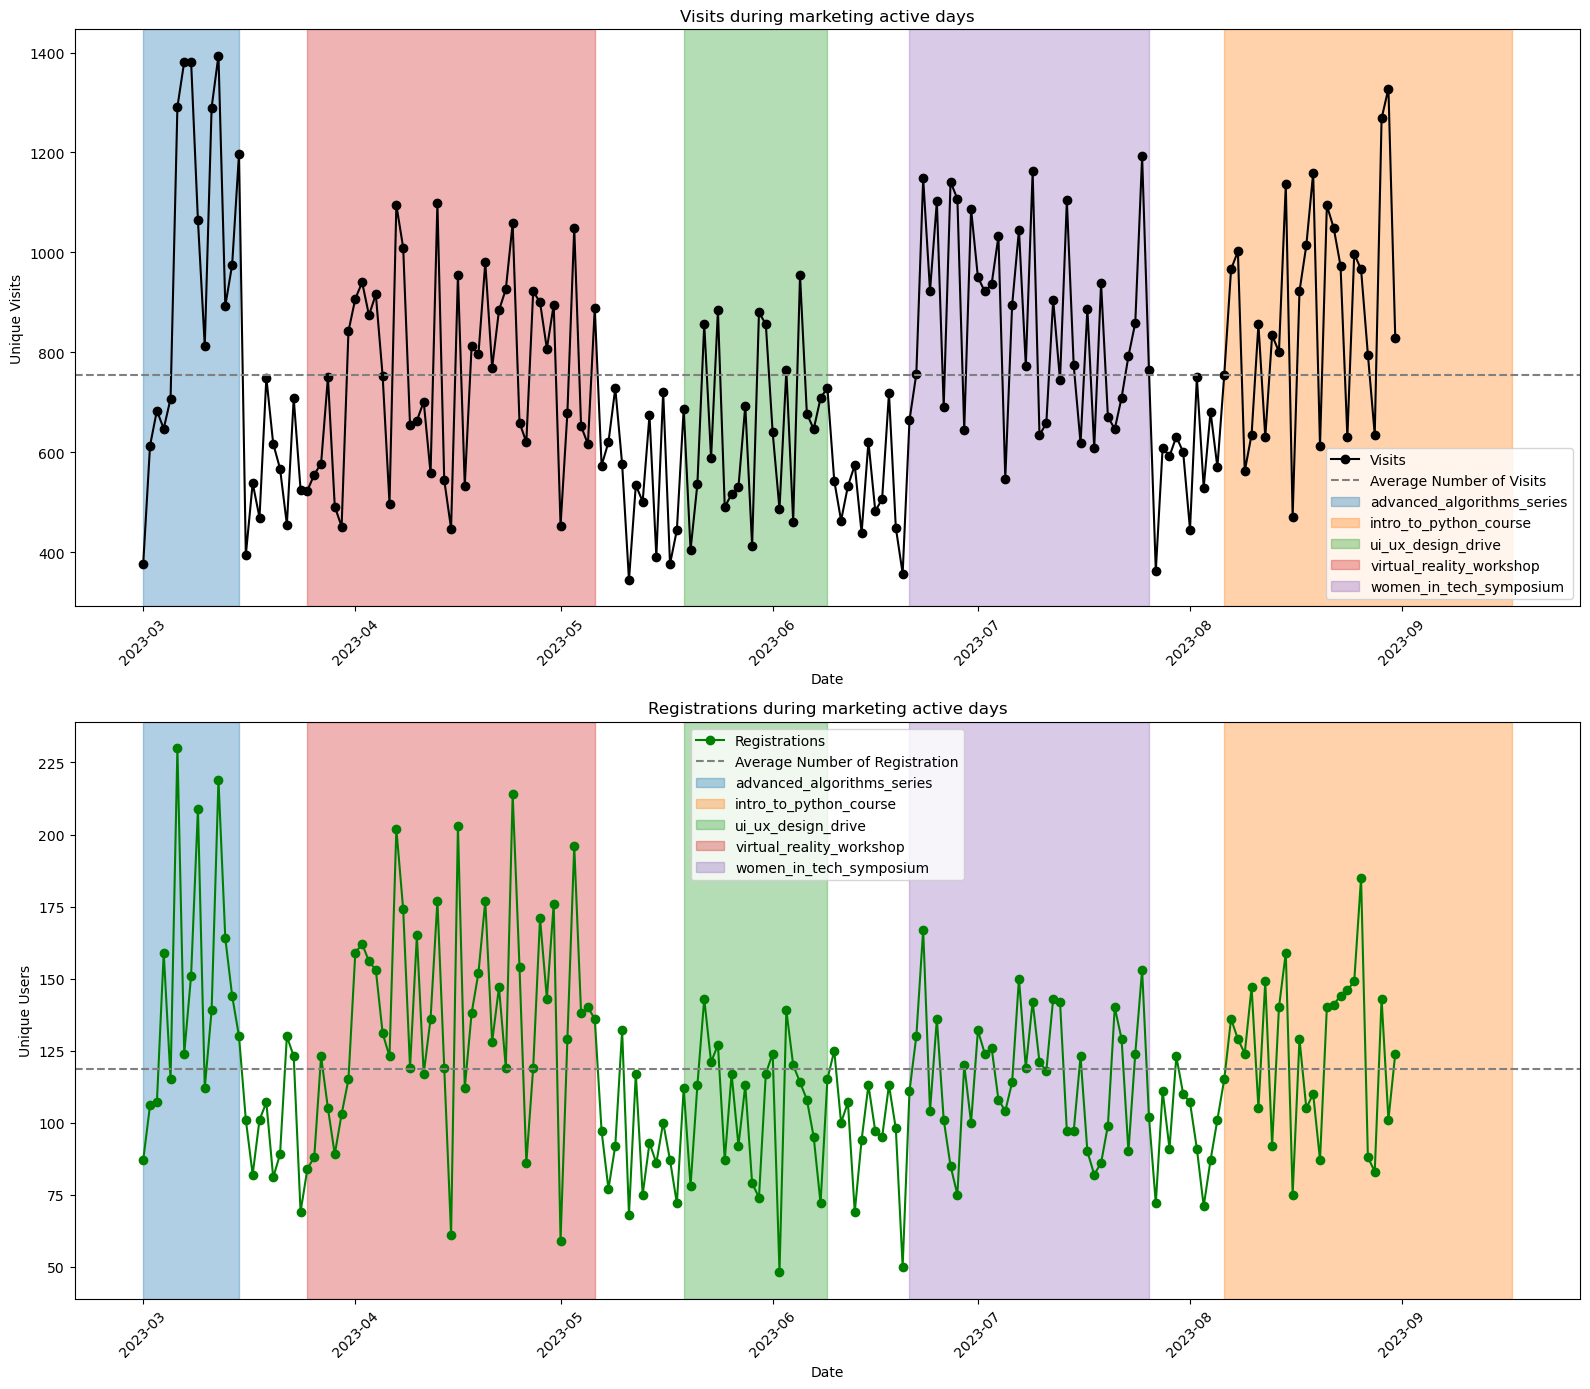

In [64]:
visits_total = df.groupby('date_group', as_index=False)['visits'].sum()
registrations_total = df.groupby('date_group', as_index=False)['registrations'].sum()

ads_periods = ads.groupby('utm_campaign', as_index=False).agg(
    start_date=('date_group', 'min'),
    end_date=('date_group', 'max')
)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# --- Верхний график визиты
axes[0].plot(
    visits_total['date_group'],
    visits_total['visits'],
    color='black',
    marker='o',
    label='Visits'
)

avg_visits = visits_total['visits'].mean()
axes[0].axhline(
    avg_visits,
    linestyle='--',
    color='gray',
    label='Average Number of Visits'
)

for i, row in ads_periods.iterrows():
    axes[0].axvspan(
        row['start_date'],
        row['end_date'],
        alpha=0.35,
        color=colors[i % len(colors)],
        label=row['utm_campaign']
    )

axes[0].set_title('Visits during marketing active days')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Unique Visits')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

#  Нижний график регистрации
axes[1].plot(
    registrations_total['date_group'],
    registrations_total['registrations'],
    color='green',
    marker='o',
    label='Registrations'
)

avg_registrations = registrations_total['registrations'].mean()
axes[1].axhline(
    avg_registrations,
    linestyle='--',
    color='gray',
    label='Average Number of Registration'
)

for i, row in ads_periods.iterrows():
    axes[1].axvspan(
        row['start_date'],
        row['end_date'],
        alpha=0.35,
        color=colors[i % len(colors)],
        label=row['utm_campaign']
    )

axes[1].set_title('Registrations during marketing active days')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Unique Users')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('./charts/marketing_active_days.png')
plt.show()